In [37]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch_directml
import torch.nn as nn

import torch.nn as nn

class MelDiscriminator(nn.Module):
    """Discriminator for (1, 64, 512) mel spectrograms."""
    def __init__(self, features_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            # (1, 64, 512) → (features_dim, 32, 256)
            nn.Conv2d(1, features_dim, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*2, 16, 128)
            nn.Conv2d(features_dim, features_dim*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*2),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*4, 8, 64)
            nn.Conv2d(features_dim*2, features_dim*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*4),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*8, 4, 32)
            nn.Conv2d(features_dim*4, features_dim*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*8),
            nn.LeakyReLU(0.2, inplace=True),
            # → (features_dim*16, 2, 16)
            nn.Conv2d(features_dim*8, features_dim*16, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*16),
            nn.LeakyReLU(0.2, inplace=True),
            # → (1, 1, 1) — final real/fake score
            nn.Conv2d(features_dim*16, 1, kernel_size=(2, 16), stride=1, padding=0, bias=False),
        )

    def forward(self, x):
        return self.net(x)


class MelGenerator(nn.Module):
    """Generator producing (1, 64, 512) mel spectrograms from latent vector."""
    def __init__(self, latent_dim=100, features_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            # Input: (latent_dim, 1, 1)
            # → (features_dim*16, 2, 16)
            nn.ConvTranspose2d(latent_dim, features_dim*16, kernel_size=(2, 16), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_dim*16),
            nn.ReLU(True),
            # → (features_dim*8, 4, 32)
            nn.ConvTranspose2d(features_dim*16, features_dim*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*8),
            nn.ReLU(True),
            # → (features_dim*4, 8, 64)
            nn.ConvTranspose2d(features_dim*8, features_dim*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*4),
            nn.ReLU(True),
            # → (features_dim*2, 16, 128)
            nn.ConvTranspose2d(features_dim*4, features_dim*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim*2),
            nn.ReLU(True),
            # → (features_dim, 32, 256)
            nn.ConvTranspose2d(features_dim*2, features_dim, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_dim),
            nn.ReLU(True),
            # → (1, 64, 512)
            nn.ConvTranspose2d(features_dim, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)
    
class MelChunkDataset(Dataset):
    def __init__(self, npy_path):
        data = np.load(npy_path)
        self.data = torch.from_numpy(data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        chunk = self.data[idx]                          # (1, 64, 431)
        chunk = torch.nn.functional.pad(chunk, (0, 81)) # pad to (1, 64, 512)
        return chunk
      

dataset = MelChunkDataset("mel_electronic_dataset.npy")
loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True)

print(f"Dataset size: {len(dataset)} chunks")
print(f"Batch shape: {next(iter(loader)).shape}")  # should be (128, 1, 64, 256)

Dataset size: 9990 chunks
Batch shape: torch.Size([128, 1, 64, 512])


## Defining the Generator and Discriminator

Determine the device to be used in the computations ...

In [38]:
import torch_directml

def get_device():
    """Select device where to perform the computations."""
    if torch_directml.is_available():
        return torch_directml.device()
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Selected device: {device}")

Selected device: privateuseone:0


... instantiate the generator ...

In [39]:
import deeplay as dl

latent_dim = 100
features_dim = 64

gen = MelGenerator(latent_dim=latent_dim, features_dim=features_dim).to(device)

... and instantiate the discriminator.

In [40]:
disc = MelDiscriminator(features_dim=features_dim).to(device)

## Training the GAN

Define the data loader ...

... define the loss function ...

In [41]:
criterion = nn.BCEWithLogitsLoss()

... define the optimizers ...

In [42]:
optim_gen = torch.optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
optim_disc = torch.optim.Adam(disc.parameters(), lr=0.0002, betas=(0.5, 0.999))

... implement the adversarial training ...

In [43]:
import time
from datetime import timedelta

epochs = 20
batch_size = 128
num_batches = len(loader)
gen_losses_avg, disc_losses_avg = [], []
fix_latent_vector = torch.randn(30, latent_dim, 1, 1).to(device)
for epoch in range(epochs):
    gen.train(), disc.train()

    print("\n" + f"Epoch {epoch + 1 }/{epochs}" + "\n" + "-" * 10)
    start_time = time.time()

    running_gen_loss, running_disc_loss = 0.0, 0.0
    for batch_idx, real_images in enumerate(loader):
        real_images = real_images.to(device)

        noise = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake_images = gen(noise)

        # 1. Discriminator training: minimize - log(D(x)) - log(1 - D(G(z))).
        real_output = disc(real_images).reshape(-1)
        fake_output = disc(fake_images).reshape(-1)

        real_loss = criterion(real_output, torch.ones_like(real_output))
        fake_loss = criterion(fake_output, torch.zeros_like(fake_output))

        disc_loss = (real_loss + fake_loss) / 2

        optim_disc.zero_grad()
        disc_loss.backward(retain_graph=True)
        optim_disc.step()

        # 2. Generator training: minimize - log(D(G(z))).
        fake_output = disc(fake_images).reshape(-1)
        gen_loss = criterion(fake_output, torch.ones_like(fake_output))

        optim_gen.zero_grad()
        gen_loss.backward()
        optim_gen.step()

        if batch_idx % 5 == 0:
            print(f"Batch {batch_idx + 1}/{num_batches}: "
                  f"Generator Loss: {gen_loss.item():.4f}, "
                  f"Discriminator Loss: {disc_loss.item():.4f}")

        running_gen_loss += gen_loss.item()
        running_disc_loss += disc_loss.item()

    gen_losses_avg.append(running_gen_loss / num_batches)
    disc_losses_avg.append(running_disc_loss / num_batches)
    end_time = time.time()

    print("-" * 10 + "\n" + f"Epoch {epoch + 1}/{epochs}: "
          f"Generator Loss: {gen_losses_avg[-1]:.4f}, "
          f"Discriminator Loss: {disc_losses_avg[-1]:.4f}, "
          f"Time taken: {timedelta(seconds=end_time - start_time)}")
    torch.save({'epoch' : epoch + 1,
                'gen_state_dict' :gen.state_dict(),
                'gen_losses' : gen_losses_avg,
                'disc_losses' : disc_losses_avg,
    }, f"gan_checkpoint_epoch{epoch+1}.pt")
    '''
    gen.eval(), disc.eval()
    fake_images = gen(fix_latent_vector).detach().cpu().numpy()

    fig, axs = plt.subplots(3, 10, figsize=(20, 6))
    for i, ax in enumerate(axs.ravel()):
        ax.imshow(fake_images[i][0], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    '''


Epoch 1/20
----------
Batch 1/79: Generator Loss: 4.0494, Discriminator Loss: 0.6962
Batch 6/79: Generator Loss: 8.0540, Discriminator Loss: 0.0528
Batch 11/79: Generator Loss: 11.9067, Discriminator Loss: 0.0412
Batch 16/79: Generator Loss: 11.2992, Discriminator Loss: 0.0071
Batch 21/79: Generator Loss: 7.7944, Discriminator Loss: 0.0048
Batch 26/79: Generator Loss: 19.4244, Discriminator Loss: 1.6779
Batch 31/79: Generator Loss: 6.8589, Discriminator Loss: 0.0090
Batch 36/79: Generator Loss: 5.7338, Discriminator Loss: 0.0564
Batch 41/79: Generator Loss: 7.0360, Discriminator Loss: 0.0362
Batch 46/79: Generator Loss: 14.2895, Discriminator Loss: 0.2403
Batch 51/79: Generator Loss: 11.1326, Discriminator Loss: 0.0489
Batch 56/79: Generator Loss: 8.0325, Discriminator Loss: 0.0175
Batch 61/79: Generator Loss: 6.9849, Discriminator Loss: 0.0153
Batch 66/79: Generator Loss: 12.7171, Discriminator Loss: 0.4971
Batch 71/79: Generator Loss: 6.2833, Discriminator Loss: 0.0428
Batch 76/79: 

## Plotting the Training Losses

In [44]:
SR = 22050           # sample rate
N_FFT = 1024         # FFT window size
HOP_LENGTH = 256     # hop length
N_MELS = 64          # mel frequency bins


def mel_chunk_to_audio(chunk, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Convert a single (1, n_mels, chunk_frames) chunk back to audio"""
    mel_norm = chunk.squeeze()             # (n_mels, chunk_frames)
    mel_db = mel_norm * 40 - 40            # denormalize
    mel_power = librosa.db_to_power(mel_db)
    audio = librosa.feature.inverse.mel_to_audio(mel_power, sr=sr,
                                                  n_fft=n_fft,
                                                  hop_length=hop_length)
    return audio

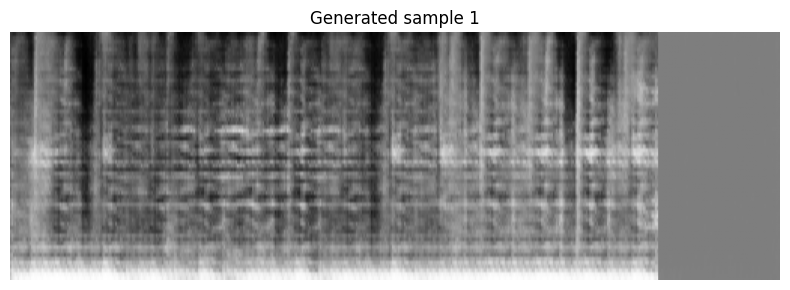

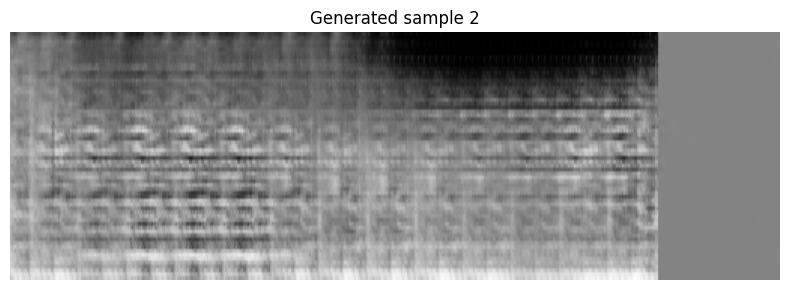

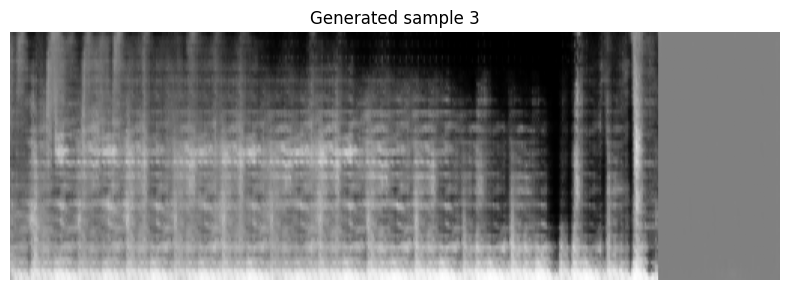

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa

gen.eval()
fake_images = gen(fix_latent_vector).detach().cpu().numpy()

for i in range(3):
    audio = mel_chunk_to_audio(fake_images[i])
    
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.imshow(fake_images[i][0], cmap="gray", origin="lower", aspect="auto")
    ax.axis("off")
    ax.set_title(f"Generated sample {i+1}")
    plt.tight_layout()
    plt.show()
    
    ipd.display(ipd.Audio(audio, rate=SR))

C:\Users\Izabella\AppData\Local\Temp\ipykernel_22488\1209111500.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("gan_checkpoint_epoch20.pt", map_

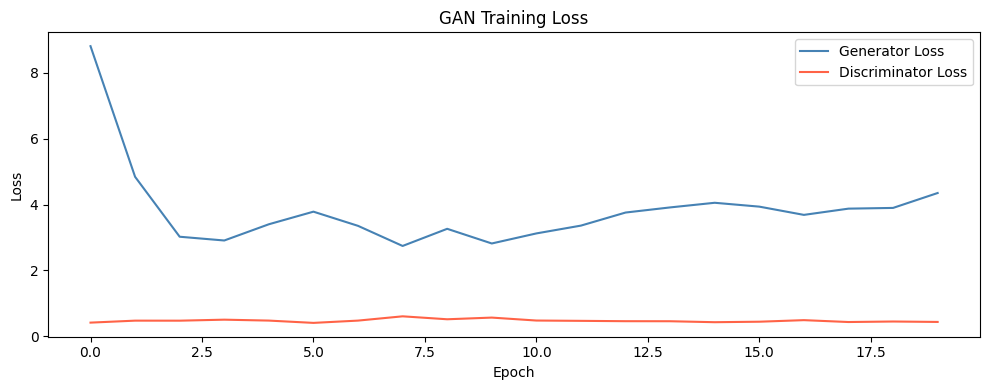

In [47]:
checkpoint = torch.load("gan_checkpoint_epoch20.pt", map_location="cpu")

gen_losses_avg  = checkpoint["gen_losses"]
disc_losses_avg = checkpoint["disc_losses"]

plt.figure(figsize=(10, 4))
plt.plot(gen_losses_avg, label="Generator Loss", color="steelblue")
plt.plot(disc_losses_avg, label="Discriminator Loss", color="tomato")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.tight_layout()
plt.show()